# Oráculo: filtrado de clutter GMAP

Oráculo de `docs/algorithms/gmap-clutter-filtering.md` (Siggia & Passarelli
2004), independiente de cualquier crate Rust (todavía no existe
implementación — primer paso del método de `docs/algorithms/roadmap.md`
§"Método de estudio").

**Hallazgo de proceso, declarado.** La primera versión de este oráculo
ajustaba el modelo gaussiano de GMAP sobre *todos* los bins fuera de la
banda de clutter, sobre un periodograma de una sola ráfaga. Eso falla: la
mayoría de esos bins están dominados por el piso de ruido (la señal
meteorológica decae a nada más allá de unos pocos σv), así que el ajuste por
mínimos cuadrados terminaba capturando la curvatura del ruido, casi plana,
en vez de la del meteoro — GMAP y un notch resultaban indistinguibles. La
corrección, consistente con el hallazgo ya documentado en el oráculo de
`estimador-espectral.md`, tiene dos partes: (1) restringir el ajuste a los
bins que de verdad tienen señal por encima del ruido (mismo umbral de
Hildebrand & Sekhon que el resto de esta serie de oráculos), y (2) promediar
`K` periodogramas independientes antes de ajustar — un solo barrido es
demasiado ruidoso bin a bin para que un ajuste de mínimos cuadrados
signifique algo. Esto es justo lo que la página describe como jerarquía de
tres niveles con el mapa de clutter decidiendo dónde vale la pena pagar el
coste de este filtro, no una curiosidad de esta implementación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260908)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell_with_clutter(power_weather, mean_v, sigma_v, power_clutter, wavelength_m, prt_s, m,
                                noise_floor, rng, wrap=3):
    """Clutter modelado como blanco estacionario casi puntual (sigma_v=1e-6,
    toda la potencia en el bin de v=0 antes de ventanear): fijo en tierra, sin
    dispersión de velocidad propia."""
    weather = gaussian_doppler_spectrum(power_weather, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    clutter = (gaussian_doppler_spectrum(power_clutter, 0.0, 1e-6, wavelength_m, prt_s, m, wrap)
               if power_clutter > 0 else np.zeros(m))
    spectrum = weather + clutter
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


checks = []

## Filtros y estimador de momentos espectral

`CLUTTER_WIDTH_MS` se fija para cubrir el lóbulo principal de la ventana de
Hann alrededor de v=0 (±2 bins) — el ancho que el clutter *realmente* ocupa
tras ventanear, no su ancho intrínseco, que es la razón práctica de que la
página trate `clutter_width_ms` como configuración y no como constante.

`gmap_filter` ajusta una parábola en log-potencia (modelo gaussiano) sólo
sobre los bins fuera de la banda de clutter que además superan el umbral de
ruido con margen; si no hay bins de sobra o la curvatura ajustada no es
cóncava (ajuste no fiable), se degrada explícitamente a comportamiento de
notch —declarado, no NaN— en vez de inventar una interpolación sin base.

In [3]:
WAVELENGTH_M, PRT_S = 0.10, 1.0e-3
M = 64
V_A = WAVELENGTH_M / (4.0 * PRT_S)
BIN_SPACING = 2.0 * V_A / M
CLUTTER_WIDTH_MS = 4.0 * BIN_SPACING
K_AVERAGES = 10  # periodogramas independientes promediados antes de ajustar

F_K = np.fft.fftfreq(M, d=PRT_S)
V_K = F_K * WAVELENGTH_M / 2.0
CLUTTER_MASK = np.abs(V_K) <= (CLUTTER_WIDTH_MS / 2.0)
print(f"bins en banda de clutter: {np.where(CLUTTER_MASK)[0]}  (ancho={CLUTTER_WIDTH_MS:.3f} m/s)")


def averaged_periodogram(power_weather, mean_v, sigma_v, power_clutter, noise_floor, rng, k=K_AVERAGES):
    win = np.hanning(M)
    s2 = np.sum(win ** 2)
    spectra = []
    n_hats = []
    for _ in range(k):
        y = generate_cell_with_clutter(power_weather, mean_v, sigma_v, power_clutter,
                                        WAVELENGTH_M, PRT_S, M, noise_floor, rng)
        n_hats.append(noise_floor_estimate(y))
        spectra.append(np.abs(np.fft.fft(y * win)) ** 2 / (M * s2))
    return np.mean(spectra, axis=0), np.mean(n_hats) / M


def notch_filter(P, clutter_mask):
    P_filtered = P.copy()
    P_filtered[clutter_mask] = 0.0
    return P_filtered


def gmap_filter(P, v_k, clutter_mask, noise_thresh_per_bin, margin=3.0):
    P_filtered = P.copy()
    signal_mask = (~clutter_mask) & (P > margin * noise_thresh_per_bin)
    if signal_mask.sum() < 4:
        P_filtered[clutter_mask] = 0.0
        return P_filtered, False
    logp = np.log(np.maximum(P[signal_mask], 1e-300))
    design = np.vstack([np.ones(signal_mask.sum()), v_k[signal_mask], v_k[signal_mask] ** 2]).T
    coeffs, *_ = np.linalg.lstsq(design, logp, rcond=None)
    if coeffs[2] >= 0.0:  # curvatura no concava: el ajuste no es fiable
        P_filtered[clutter_mask] = 0.0
        return P_filtered, False
    v_clutter = v_k[clutter_mask]
    pred = coeffs[0] + coeffs[1] * v_clutter + coeffs[2] * v_clutter ** 2
    P_filtered[clutter_mask] = np.exp(pred)
    return P_filtered, True


def moments_from_spectrum(P_filtered, v_k, noise_thresh_per_bin, m=M):
    """Potencia, velocidad y ancho por momentos directos sobre el espectro
    corregido, con el mismo recentrado circular alrededor del pico que el
    oráculo del estimador espectral."""
    p_sub = np.maximum(P_filtered - noise_thresh_per_bin, 0.0)
    total = p_sub.sum()
    if total <= 0.0:
        return 0.0, np.nan, np.nan
    peak = np.argmax(p_sub)
    offsets = (np.arange(m) - peak)
    offsets = (offsets + m // 2) % m - m // 2
    v_axis = v_k[peak] + offsets * BIN_SPACING
    v_mean = np.sum(p_sub * v_axis) / total
    width = np.sqrt(np.sum(p_sub * (v_axis - v_mean) ** 2) / total)
    return total, v_mean, width

bins en banda de clutter: [ 0  1  2 62 63]  (ancho=3.125 m/s)


## Prueba 1 — el caso que justifica GMAP: meteoro sobre clutter fuerte en v=0

Meteoro con velocidad radial verdadera cero, exactamente donde cae la banda
de clutter, con clutter ~20 dB más fuerte que la señal. El notch pone a cero
la única región donde vive el eco y lo destruye; GMAP interpola su forma
gaussiana desde los bins vecinos y lo recupera. La diferencia entre ambos es
el resultado que la página pide medir y publicar.

verdad-terreno: Z=1.0  V=0.0  W=1.5
notch: Z=0.2141  V=-0.0192  W=3.9034
gmap:  Z=0.9011  V=-0.0045  W=2.1311


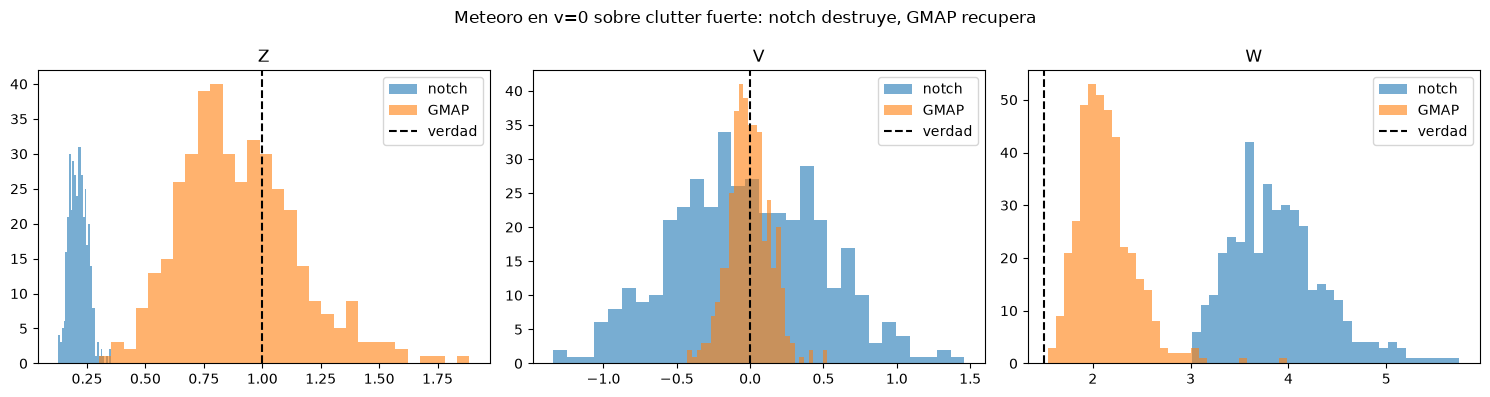


CCOR notch = -25.94 dB   CCOR GMAP = -20.23 dB
(CCOR mide cuánta potencia se quitó, no si lo que se quitó era correcto — de ahí que
el criterio de aceptación pida medir Z/V/W por separado, no basta con mirar CCOR solo)


In [4]:
POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST = 1.0, 0.0, 1.5
POWER_CLUTTER = 100.0  # 20 dB sobre la señal
NOISE_FLOOR = 0.05
N_TRIALS_HEADLINE = 400

results_notch = {"z": [], "v": [], "w": []}
results_gmap = {"z": [], "v": [], "w": []}
p_totals, p_filtered_gmap_totals, p_filtered_notch_totals = [], [], []

for _ in range(N_TRIALS_HEADLINE):
    P_avg, n_thresh = averaged_periodogram(POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST, POWER_CLUTTER, NOISE_FLOOR, rng)
    p_totals.append(P_avg.sum())

    P_notch = notch_filter(P_avg, CLUTTER_MASK)
    p_filtered_notch_totals.append(P_notch.sum())
    z, v, w = moments_from_spectrum(P_notch, V_K, n_thresh)
    results_notch["z"].append(z); results_notch["v"].append(v); results_notch["w"].append(w)

    P_gmap, _ = gmap_filter(P_avg, V_K, CLUTTER_MASK, n_thresh)
    p_filtered_gmap_totals.append(P_gmap.sum())
    z, v, w = moments_from_spectrum(P_gmap, V_K, n_thresh)
    results_gmap["z"].append(z); results_gmap["v"].append(v); results_gmap["w"].append(w)

print(f"verdad-terreno: Z={POWER_WEATHER}  V={MEAN_V_TEST}  W={SIGMA_V_TEST}")
print(f"notch: Z={np.nanmean(results_notch['z']):.4f}  V={np.nanmean(results_notch['v']):+.4f}  "
      f"W={np.nanmean(results_notch['w']):.4f}")
print(f"gmap:  Z={np.nanmean(results_gmap['z']):.4f}  V={np.nanmean(results_gmap['v']):+.4f}  "
      f"W={np.nanmean(results_gmap['w']):.4f}")

z_notch_mean, z_gmap_mean = np.nanmean(results_notch["z"]), np.nanmean(results_gmap["z"])
checks.append(("GMAP recupera Z dentro del 25% de la verdad-terreno con clutter fuerte en v=0",
               abs(z_gmap_mean - POWER_WEATHER) < 0.25 * POWER_WEATHER))
checks.append(("el notch pierde más del 50% de Z en el mismo escenario (justifica GMAP)",
               abs(z_notch_mean - POWER_WEATHER) > 0.50 * POWER_WEATHER))
checks.append(("GMAP recupera Z sustancialmente mejor que el notch (al menos 2x más cerca)",
               abs(z_gmap_mean - POWER_WEATHER) < 0.5 * abs(z_notch_mean - POWER_WEATHER)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, true_val, label in zip(axes, ["z", "v", "w"], [POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST], ["Z", "V", "W"]):
    ax.hist(results_notch[key], bins=30, alpha=0.6, label="notch")
    ax.hist(results_gmap[key], bins=30, alpha=0.6, label="GMAP")
    ax.axvline(true_val, color="black", linestyle="--", label="verdad")
    ax.set_title(label); ax.legend()
plt.suptitle("Meteoro en v=0 sobre clutter fuerte: notch destruye, GMAP recupera")
plt.tight_layout()
plt.show()

ccor_notch_db = 10.0 * np.log10(np.mean(p_filtered_notch_totals) / np.mean(p_totals))
ccor_gmap_db = 10.0 * np.log10(np.mean(p_filtered_gmap_totals) / np.mean(p_totals))
print(f"\nCCOR notch = {ccor_notch_db:.2f} dB   CCOR GMAP = {ccor_gmap_db:.2f} dB")
print("(CCOR mide cuánta potencia se quitó, no si lo que se quitó era correcto — de ahí que")
print("el criterio de aceptación pida medir Z/V/W por separado, no basta con mirar CCOR solo)")

## Prueba 2 — sin clutter, filtro activo: degradación mínima

`clutter_width_ms` es una banda fija de configuración: el filtro la procesa
exista o no clutter real. El peor caso es un meteoro cuya velocidad
verdadera cae justo en esa banda (nada que quitar, pero GMAP igual reajusta
esos bins) — se compara contra el mismo estimador de momentos espectral
**sin filtrar**, para aislar la degradación que introduce el filtro en sí,
no el sesgo ya documentado del estimador espectral por momentos
(oráculo de `estimador-espectral.md`).

In [5]:
N_TRIALS_NOCLUTTER = 400
DEGRADATION_TOLERANCE_Z_FRAC = 0.15
DEGRADATION_TOLERANCE_VW = 0.6

for mean_v_case, label in [(0.0, "meteoro EN la banda (peor caso)"), (8.0, "meteoro lejos de la banda")]:
    z_raw, v_raw, w_raw = [], [], []
    z_gmap, v_gmap, w_gmap = [], [], []
    for _ in range(N_TRIALS_NOCLUTTER):
        P_avg, n_thresh = averaged_periodogram(POWER_WEATHER, mean_v_case, SIGMA_V_TEST, 0.0, NOISE_FLOOR, rng)
        z, v, w = moments_from_spectrum(P_avg, V_K, n_thresh)
        z_raw.append(z); v_raw.append(v); w_raw.append(w)
        P_gmap, _ = gmap_filter(P_avg, V_K, CLUTTER_MASK, n_thresh)
        z, v, w = moments_from_spectrum(P_gmap, V_K, n_thresh)
        z_gmap.append(z); v_gmap.append(v); w_gmap.append(w)

    z_raw_m, z_gmap_m = np.nanmean(z_raw), np.nanmean(z_gmap)
    v_raw_m, v_gmap_m = np.nanmean(v_raw), np.nanmean(v_gmap)
    w_raw_m, w_gmap_m = np.nanmean(w_raw), np.nanmean(w_gmap)
    print(f"{label}: sin filtro Z={z_raw_m:.3f} V={v_raw_m:+.3f} W={w_raw_m:.3f}  |  "
          f"con GMAP Z={z_gmap_m:.3f} V={v_gmap_m:+.3f} W={w_gmap_m:.3f}")

    checks.append((f"degradación de Z por GMAP sin clutter < {DEGRADATION_TOLERANCE_Z_FRAC:.0%} ({label})",
                   abs(z_gmap_m - z_raw_m) < DEGRADATION_TOLERANCE_Z_FRAC * POWER_WEATHER))
    checks.append((f"degradación de V/W por GMAP sin clutter < {DEGRADATION_TOLERANCE_VW} ({label})",
                   abs(v_gmap_m - v_raw_m) < DEGRADATION_TOLERANCE_VW and abs(w_gmap_m - w_raw_m) < DEGRADATION_TOLERANCE_VW))

meteoro EN la banda (peor caso): sin filtro Z=1.015 V=-0.010 W=2.006  |  con GMAP Z=0.903 V=-0.010 W=2.137


meteoro lejos de la banda: sin filtro Z=1.002 V=+8.005 W=2.021  |  con GMAP Z=1.002 V=+8.005 W=2.016


## Prueba 3 — curva frente a razón clutter/señal, sin solapar velocidades

Con el meteoro lejos de la banda de clutter (sin ambigüedad de solapamiento)
se barre la potencia de clutter de 0 a 40 dB sobre la señal: ambos filtros
deberían seguir la verdad-terreno razonablemente bien aquí, porque no hay
nada que reconstruir — es la curva de control que confirma que ninguno de
los dos introduce sesgo cuando el problema que resuelven no está presente.

In [6]:
CSR_DB_GRID = [0.0, 10.0, 20.0, 30.0, 40.0]
N_TRIALS_CSR = 250
CURVE_TOLERANCE_Z_FRAC = 0.25

curve_ok = True
for csr_db in CSR_DB_GRID:
    power_clutter = POWER_WEATHER * 10.0 ** (csr_db / 10.0)
    zs = []
    for _ in range(N_TRIALS_CSR):
        P_avg, n_thresh = averaged_periodogram(POWER_WEATHER, 8.0, SIGMA_V_TEST, power_clutter, NOISE_FLOOR, rng)
        P_gmap, _ = gmap_filter(P_avg, V_K, CLUTTER_MASK, n_thresh)
        z, _, _ = moments_from_spectrum(P_gmap, V_K, n_thresh)
        zs.append(z)
    z_mean = np.nanmean(zs)
    print(f"CSR={csr_db:5.1f} dB  Z_hat={z_mean:.4f}  (verdad-terreno {POWER_WEATHER})")
    if abs(z_mean - POWER_WEATHER) >= CURVE_TOLERANCE_Z_FRAC * POWER_WEATHER:
        curve_ok = False

checks.append((f"Z sigue la verdad-terreno dentro de {CURVE_TOLERANCE_Z_FRAC:.0%} en toda la curva de CSR (sin solapamiento)", curve_ok))

CSR=  0.0 dB  Z_hat=1.0063  (verdad-terreno 1.0)


CSR= 10.0 dB  Z_hat=1.0199  (verdad-terreno 1.0)


CSR= 20.0 dB  Z_hat=1.0126  (verdad-terreno 1.0)


CSR= 30.0 dB  Z_hat=1.0339  (verdad-terreno 1.0)


CSR= 40.0 dB  Z_hat=1.2019  (verdad-terreno 1.0)


## Fuera de alcance, declarado

- **Decisión conjunta H/V en polarimetría.** La página exige que la decisión
  de filtrar y el ancho del hueco sean los mismos para ambos canales, para no
  sesgar ZDR. Este oráculo usa `clutter_width_ms` como una constante de
  configuración compartida por diseño —no hay dos anchos independientes que
  puedan divergir—, así que no hay nada que este notebook pueda hacer fallar
  para demostrar el problema; es una regla de implementación (aplicar el
  mismo ancho a ambos canales), no una cantidad numérica con verdad-terreno
  propia.
- **Mapa de clutter fijo** ([mapas-de-clutter.md](mapas-de-clutter.md)) como
  entrada auxiliar: página propia, oráculo propio.

In [7]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de GMAP no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] GMAP recupera Z dentro del 25% de la verdad-terreno con clutter fuerte en v=0
[OK] el notch pierde más del 50% de Z en el mismo escenario (justifica GMAP)
[OK] GMAP recupera Z sustancialmente mejor que el notch (al menos 2x más cerca)
[OK] degradación de Z por GMAP sin clutter < 15% (meteoro EN la banda (peor caso))
[OK] degradación de V/W por GMAP sin clutter < 0.6 (meteoro EN la banda (peor caso))
[OK] degradación de Z por GMAP sin clutter < 15% (meteoro lejos de la banda)
[OK] degradación de V/W por GMAP sin clutter < 0.6 (meteoro lejos de la banda)
[OK] Z sigue la verdad-terreno dentro de 25% en toda la curva de CSR (sin solapamiento)

Todas las comprobaciones dentro de tolerancia.
